[2026-07-20 10:40:29] [info     ] 因子形状: (242000, 3)
        date instrument    factor
0 2024-01-02  000006.SZ  0.981231
1 2024-01-03  000006.SZ -0.027703
2 2024-01-04  000006.SZ -0.003117
3 2024-01-05  000006.SZ -0.067867
4 2024-01-08  000006.SZ  0.199026
count    242000.000000
mean          2.480953
std         120.698171
min          -0.210317
25%          -0.003153
50%           0.159642
75%           0.669973
max       47670.405718
Name: factor, dtype: float64
[2026-07-20 10:40:29] [warning  ] bigalpha_eval._latest version='v4' (use ._latest for dev only, not for prod)
[2026-07-20 10:40:31] [info     ] bigalpha_eval.v4 开始运行 ..
[2026-07-20 10:40:32] [info     ] 对齐中证1000历史成分后，官方评估窗口: 2024-01-02 至 2024-12-31
[2026-07-20 10:40:32] [info     ] ========== 数据检查 ==========
[2026-07-20 10:40:32] [info     ] 通过：列名检查（date/instrument + 至少 1 个因子列） factor_cols=['factor', 'close', 'volume', 'amount', 'turn', 'change_ratio', 'daily_return', 'momentum_5', 'reversal_5', 'volatility_5', 'total_market

时段,IC
2024-01-15~2024-02-08,0.0520
2024-09-24~2024-10-08,-0.0040

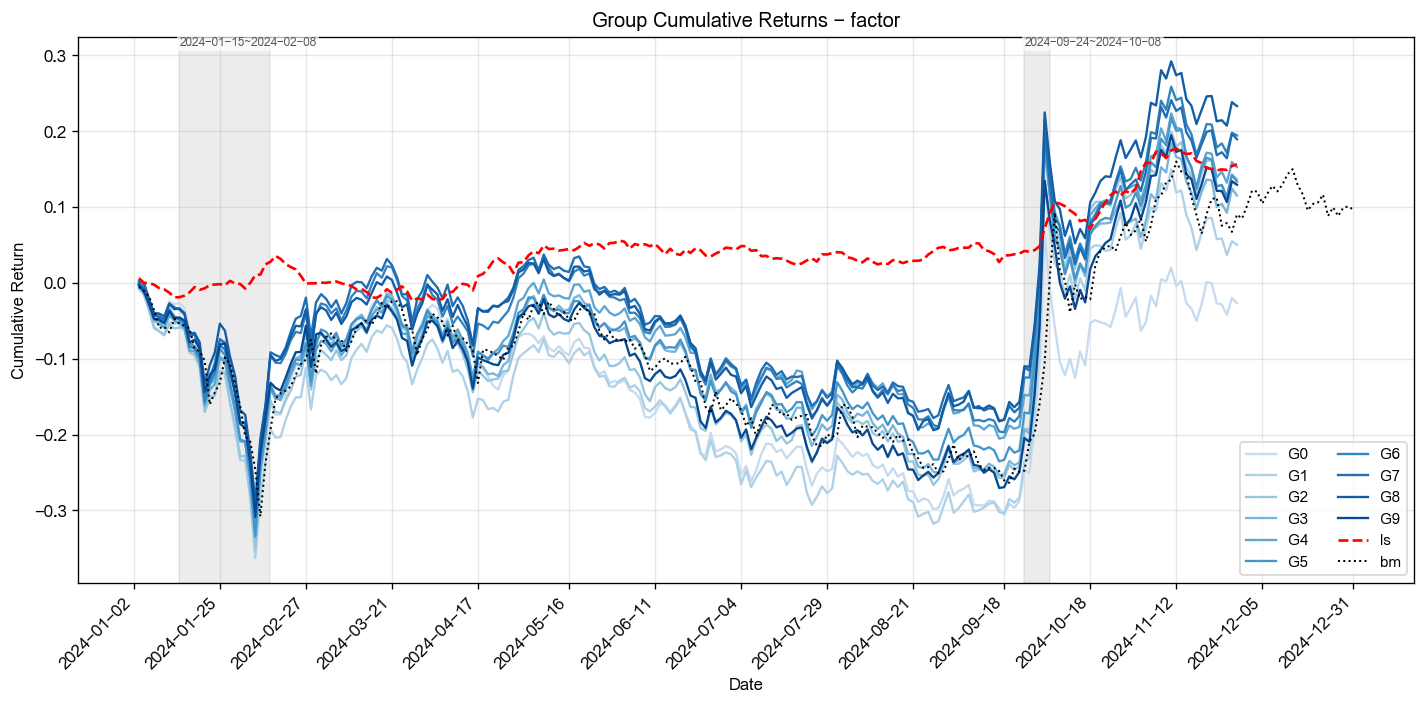
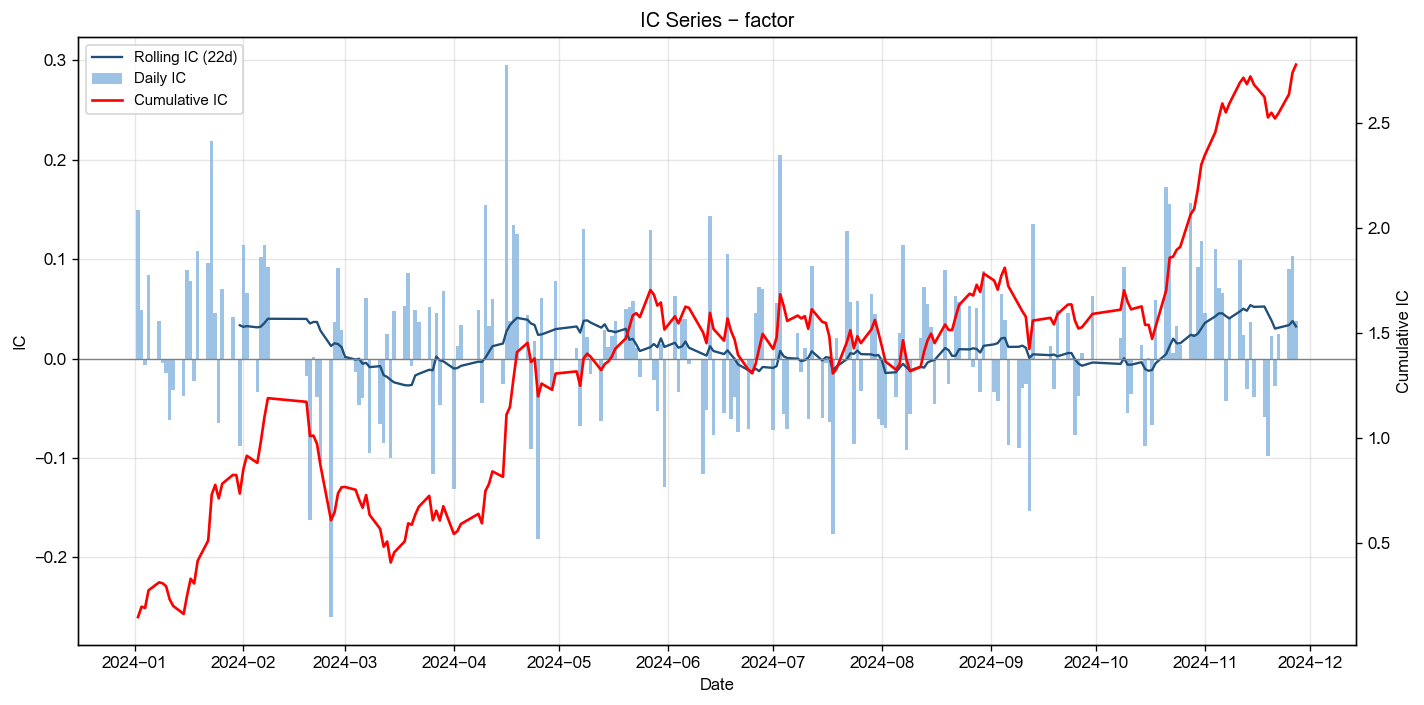
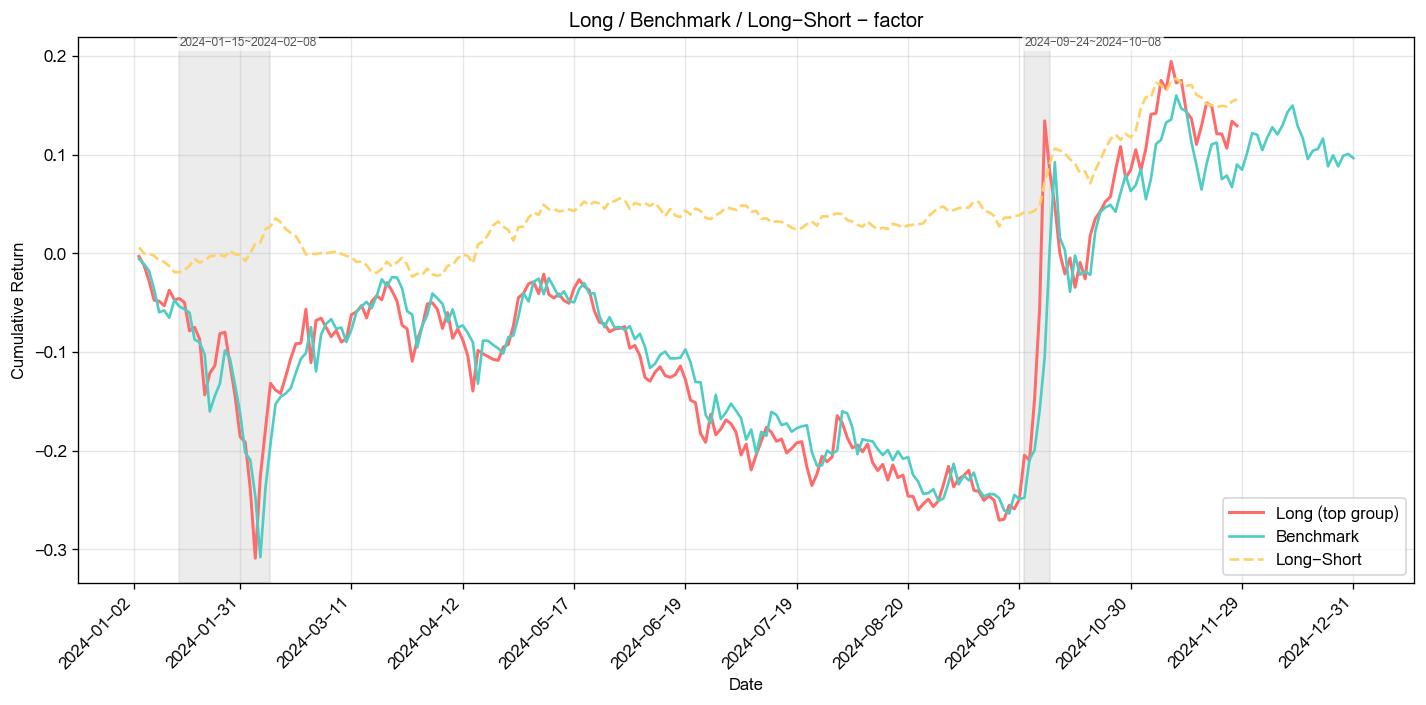
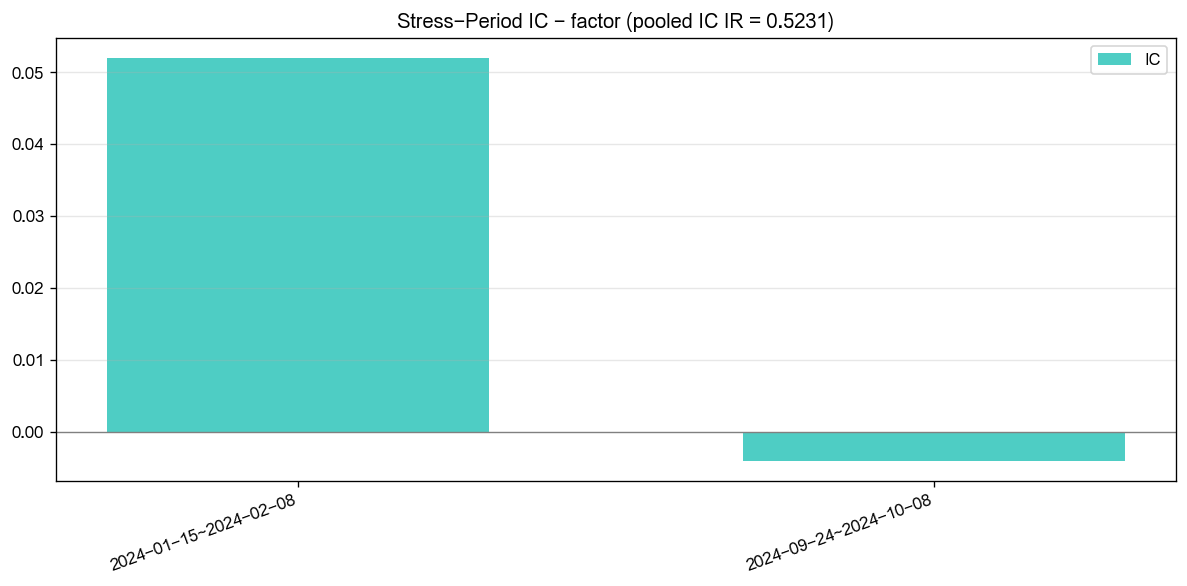
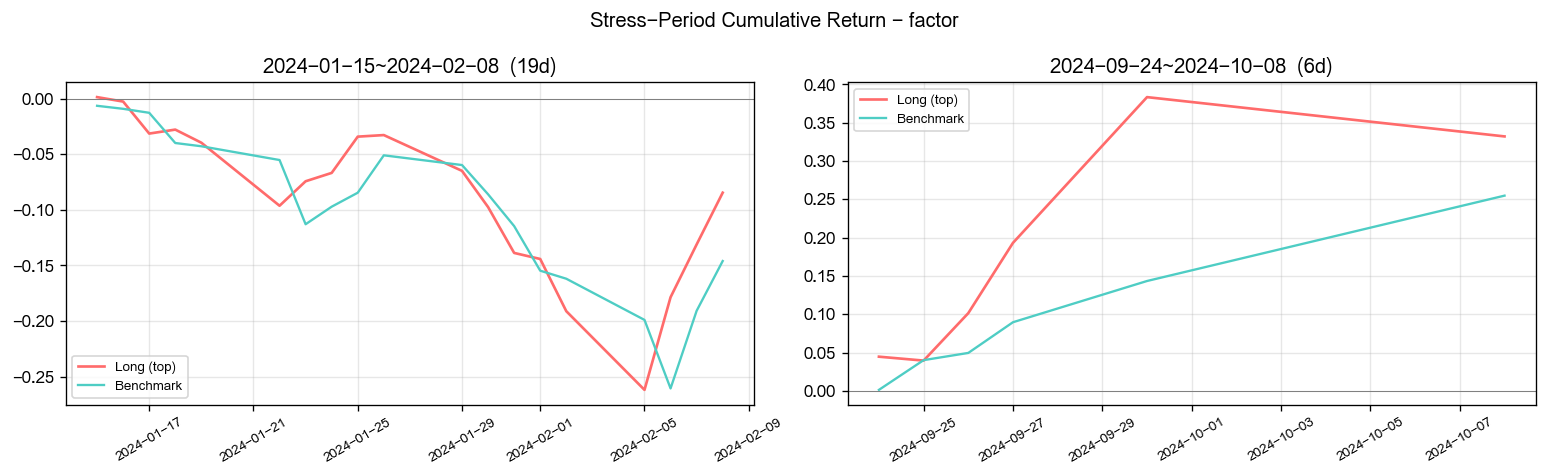

[2026-07-20 10:40:52] [info     ] ========== 因子池回归 ==========
[2026-07-20 10:40:52] [info     ] 加载 T+1 收益数据完成                  end_date=2024-12-31 instrument_count=1206 rows=297953 start_date=2024-01-02
[2026-07-20 10:40:53] [info     ] 获取收益率数据, 耗时: 0.6307 秒
[2026-07-20 10:40:53] [info     ] 滚动 Elastic Net 拟合, 耗时: 0.6223 秒
[2026-07-20 10:40:53] [info     ] 统计 回归结果, 耗时: 0.0083 秒


#,因子名,ModelScore,mean(|w|),std(|w|),入选率
1,rsi_12,1.9339,0.0446,0.0230,1.0000
2,amount,1.7088,0.0185,0.0108,0.9000
3,netflow_amount_rate_main,1.5381,0.0099,0.0065,1.0000
4,netflow_amount_main,1.5116,0.0252,0.0166,1.0000
5,gross_profit_rate_ttm,1.5093,0.0069,0.0046,1.0000
6,net_profit_rate_ttm,1.4486,0.0040,0.0028,0.8000
7,pb,1.4226,0.0097,0.0068,1.0000
8,bias_20,1.4125,0.0292,0.0206,0.9000
9,cci_14,1.3845,0.0338,0.0244,1.0000
10,pe_ttm,1.3096,0.0029,0.0022,0.9000

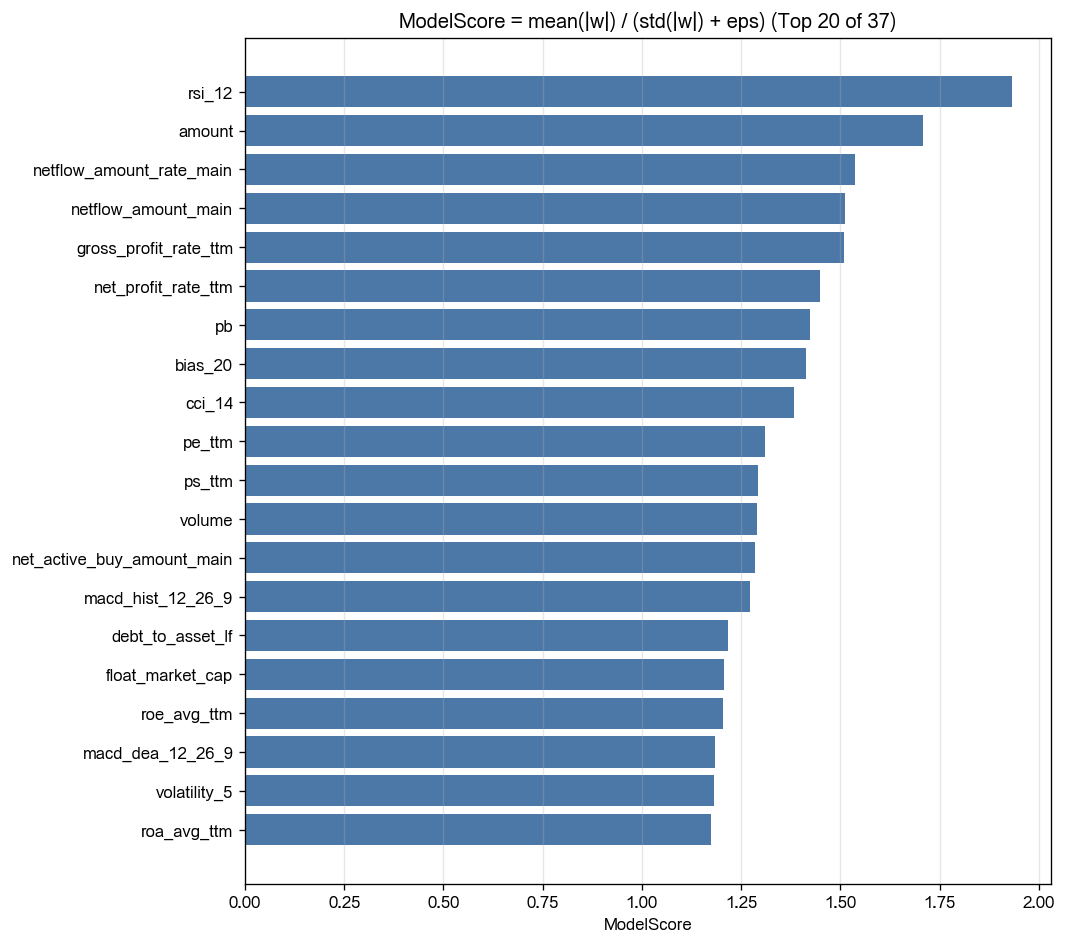
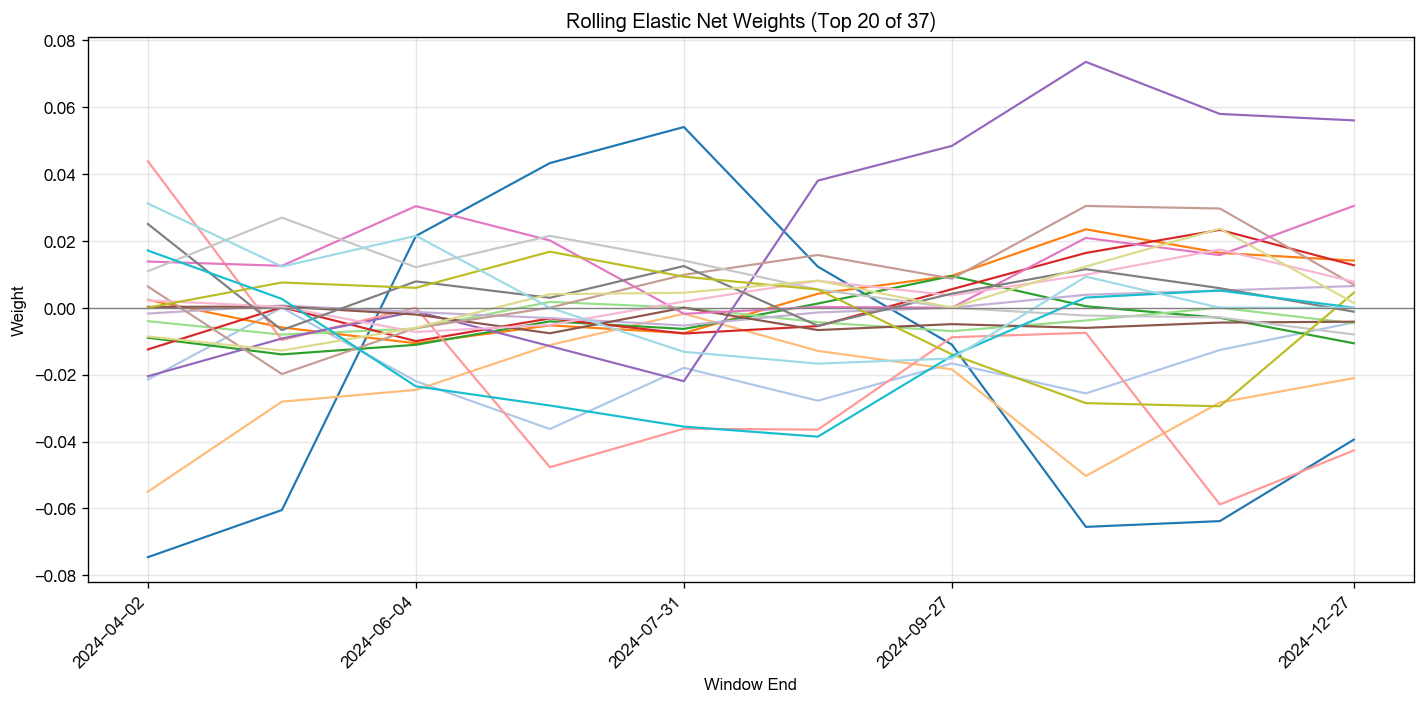
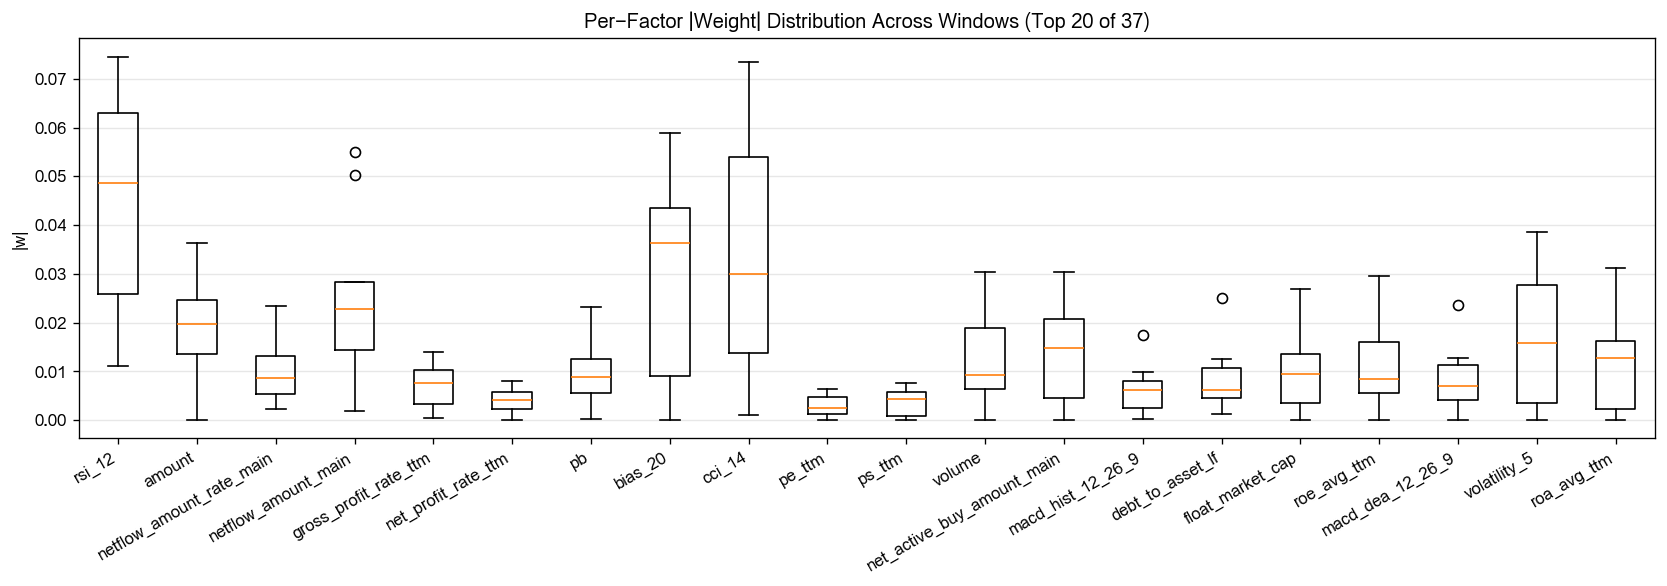
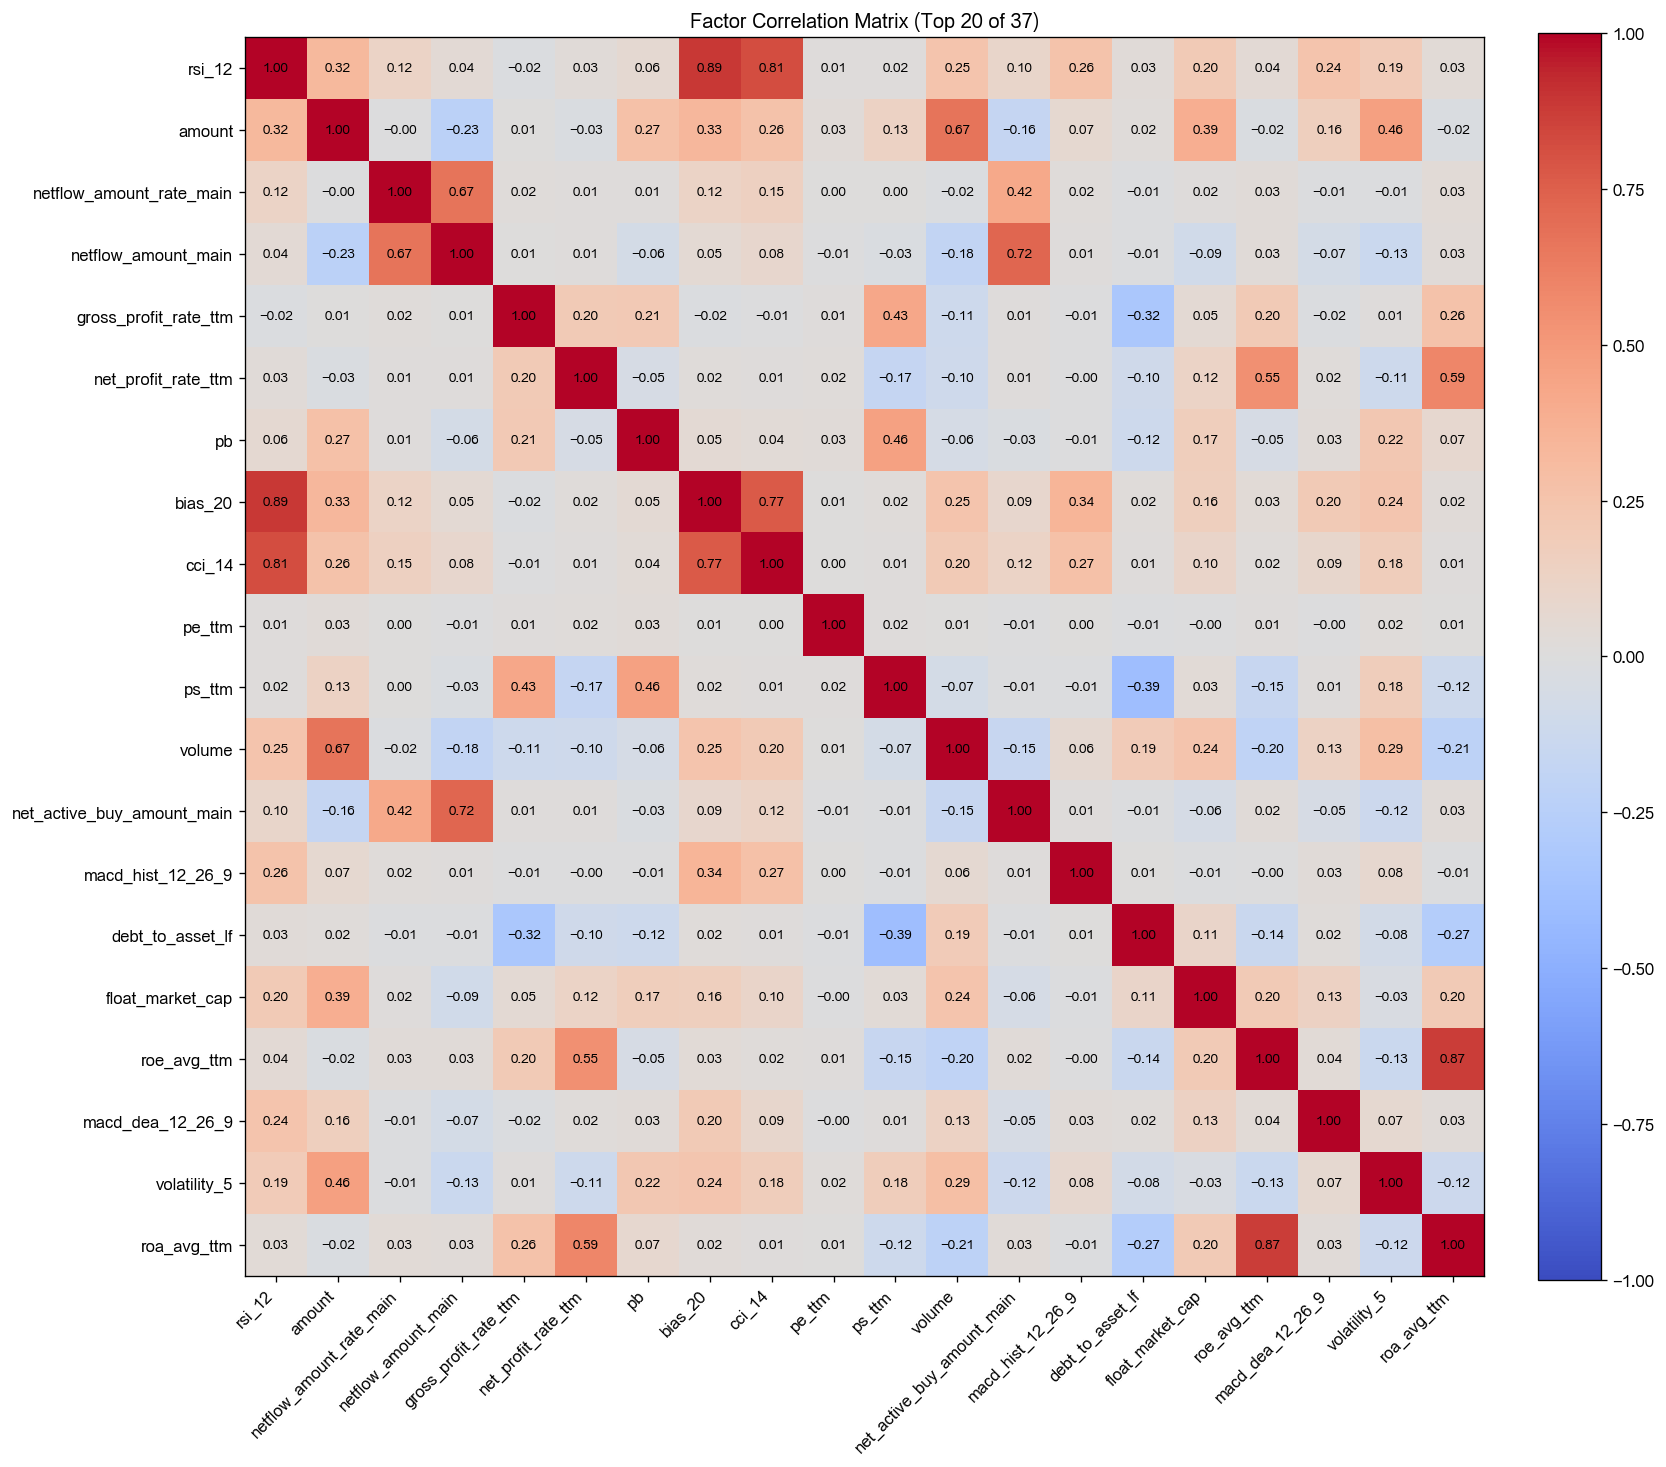

[2026-07-20 10:40:55] [warning  ] 返回的Outputs实例(size=35353239) 大于 64K, 将不会被缓存
[2026-07-20 10:40:55] [info     ] bigalpha_eval.v4 运行完成 [24.119s].


In [1]:

import pandas as pd
import numpy as np
import dai

def main(datasources, start_date, end_date):
    """
    订单簿压力衰减因子（无未来函数版）
    所有聚合在DAI SQL中完成，因子值滞后一个交易日输出
    """
    bar1m = datasources["bar1m"]
    LOOKBACK = 5
    # 向前取足够多的数据（5个交易日 + 1天缓冲）
    query_start = (pd.to_datetime(start_date) - pd.Timedelta(days=LOOKBACK + 2)).strftime('%Y-%m-%d %H:%M:%S')

    # ===== 核心SQL：计算每分钟订单簿压力，再聚合为日频 =====
    sql = f"""
    WITH minute_pressure AS (
        SELECT
            date,
            instrument,
            EXTRACT(HOUR FROM date) * 60 + EXTRACT(MINUTE FROM date) AS minute_of_day,
            -- 前5档加权委买量
            bid_volume1 * 1.0 +
            bid_volume2 * 0.8 +
            bid_volume3 * 0.6 +
            bid_volume4 * 0.4 +
            bid_volume5 * 0.2 AS weighted_bid,
            -- 前5档加权委卖量
            ask_volume1 * 1.0 +
            ask_volume2 * 0.8 +
            ask_volume3 * 0.6 +
            ask_volume4 * 0.4 +
            ask_volume5 * 0.2 AS weighted_ask
        FROM {bar1m}
        WHERE
            ask_price1 > 0 AND bid_price1 > 0
            AND ask_volume1 > 0 AND bid_volume1 > 0
            AND date >= '{query_start}'   -- 扩展查询范围，保证滞后需要的数据
    ),
    minute_imbalance AS (
        SELECT
            date,
            instrument,
            minute_of_day,
            (weighted_bid - weighted_ask) / (weighted_bid + weighted_ask + 1e-8) AS imbalance
        FROM minute_pressure
    ),
    daily_pressure AS (
        SELECT
            date::DATE AS date,
            instrument,
            AVG(CASE WHEN minute_of_day BETWEEN 570 AND 600 THEN imbalance END) AS open_pressure,
            AVG(CASE WHEN minute_of_day BETWEEN 870 AND 900 THEN imbalance END) AS close_pressure
        FROM minute_imbalance
        GROUP BY date::DATE, instrument
        HAVING COUNT(CASE WHEN minute_of_day BETWEEN 570 AND 600 THEN 1 END) > 0
           AND COUNT(CASE WHEN minute_of_day BETWEEN 870 AND 900 THEN 1 END) > 0
    )
    SELECT
        date,
        instrument,
        -- 因子 = - (open_pressure - close_pressure) / (|open_pressure| + 1e-8) * close_pressure
        - (open_pressure - close_pressure) / (ABS(open_pressure) + 1e-8) * close_pressure AS factor
    FROM daily_pressure
    """
    # 查询时不加 filters，因为已在 SQL 中限定了下界
    df = dai.query(sql, compression=True).df()
    if df.empty:
        return pd.DataFrame(columns=['date', 'instrument', 'factor'])

    # ---- 类型转换 ----
    df['date'] = pd.to_datetime(df['date'])
    df['instrument'] = df['instrument'].astype(str)
    df['factor'] = pd.to_numeric(df['factor'], errors='coerce')

    # ---- 获取中证1000成分股（股票池） ----
    stk_pool = dai.query(
        "SELECT date, instrument FROM bigalpha_2026_instruments",
        filters={'date': [start_date, end_date]},  # 只取正式区间
        compression=True
    ).df()
    stk_pool['date'] = pd.to_datetime(stk_pool['date'])
    stk_pool['instrument'] = stk_pool['instrument'].astype(str)

    # ---- 滞后合并：为每个股票独立做 merge_asof，确保不使用当日因子 ----
    final_dfs = []
    # 按股票分组，避免跨股票错误匹配
    for inst, group in stk_pool.groupby('instrument'):
        # 取出该股票的历史因子（按日期排序）
        factor_series = df[df['instrument'] == inst].sort_values('date')
        if factor_series.empty:
            group['factor'] = np.nan
            final_dfs.append(group)
            continue

        # merge_asof: 左侧为股票池日期（需要因子值的日期）
        # direction='backward' 选择右侧日期 <= 左侧日期的最近值
        # allow_exact_matches=False 禁止匹配同一日期，保证至少滞后一天
        merged = pd.merge_asof(
            group.sort_values('date'),
            factor_series[['date', 'factor']],
            on='date',
            direction='backward',
            allow_exact_matches=False
        )
        final_dfs.append(merged)

    final_df = pd.concat(final_dfs, ignore_index=True)

    # ---- 缺失值处理 ----
    final_df['factor'] = final_df['factor'].fillna(0.0)
    final_df['factor'] = final_df['factor'].replace([np.inf, -np.inf], 0.0)

    # ---- 添加微小噪声（区分零值） ----
    mask_zero = final_df['factor'] == 0
    if mask_zero.any():
        noise = final_df.loc[mask_zero, 'instrument'].apply(
            lambda x: (hash(x) % 10000) / 10000000.0
        )
        final_df.loc[mask_zero, 'factor'] = -0.001 + noise

    # ---- 确保日期在正式区间内（合并过程中可能引入更早的日期，但我们已经过滤掉） ----
    final_df = final_df[(final_df['date'] >= pd.to_datetime(start_date)) &
                        (final_df['date'] <= pd.to_datetime(end_date))]

    return final_df[['date', 'instrument', 'factor']]


if __name__ == '__main__':
    from bigmodule import M
    import structlog
    logger = structlog.get_logger()

    datasources = {'bar1m': 'bigalpha_2026_stock_bar1m'}
    start_date = '2024-01-01 00:00:00'
    end_date = '2024-12-31 23:59:59'

    factor_data = main(datasources, start_date, end_date)
    logger.info(f"因子形状: {factor_data.shape}")
    print(factor_data.head())
    print(factor_data['factor'].describe())

    # 本地评测（可选）
    factor_pool = dai.query(
        "SELECT * FROM bigalpha_2026_factorlib",
        filters={'date': [start_date, end_date]},
    ).df()
    result = M.bigalpha_eval._latest(
        factor_data=factor_data,
        factor_pool=factor_pool,
        start_date=start_date,
        end_date=end_date,
        process_pools=False,
        show=True,
    )
    